In [39]:
import matplotlib.pyplot as plt
import yfinance as yf

In [6]:
eth = yf.download('ETH-USD', period='7d', interval='1h')
eth.columns = eth.columns.droplevel(1)
eth.columns = [col.lower() for col in eth.columns]
print(eth.head())
print(eth.shape)

[*********************100%***********************]  1 of 1 completed

                                 close         high          low         open  \
Datetime                                                                        
2026-09-08 00:00:00+00:00  2495.310059  2495.310059  2482.899902  2489.409912   
2026-09-08 01:00:00+00:00  2503.489990  2504.870117  2492.929932  2494.179932   
2026-09-08 02:00:00+00:00  2484.040039  2507.100098  2484.040039  2503.850098   
2026-09-08 03:00:00+00:00  2485.290039  2487.649902  2477.649902  2484.219971   
2026-09-08 04:00:00+00:00  2478.229980  2485.800049  2477.989990  2484.979980   

                           volume  
Datetime                           
2026-09-08 00:00:00+00:00       0  
2026-09-08 01:00:00+00:00       0  
2026-09-08 02:00:00+00:00       0  
2026-09-08 03:00:00+00:00       0  
2026-09-08 04:00:00+00:00       0  
(163, 5)


In [4]:
#swing high/low

def find_swings(df, n=2):
    highs = []
    lows = []
    for i in range(n, len(df)-n):
        if df['high'].iloc[i] == df['high'].iloc[i-n:i+n+1].max():
            highs.append(i)
        if df['low'].iloc[i] == df['low'].iloc[i-n:i+n+1].min():
            lows.append(i)
    return highs, lows

swing_highs, swing_lows = find_swings(eth)
print(f"Swing Highs: {len(swing_highs)}")
print(f"Swing Lows: {len(swing_lows)}")


[*********************100%***********************]  1 of 1 completed

                                 close         high          low         open  \
Datetime                                                                        
2026-09-08 00:00:00+00:00  2495.310059  2495.310059  2482.899902  2489.409912   
2026-09-08 01:00:00+00:00  2503.489990  2504.870117  2492.929932  2494.179932   
2026-09-08 02:00:00+00:00  2484.040039  2507.100098  2484.040039  2503.850098   
2026-09-08 03:00:00+00:00  2485.290039  2487.649902  2477.649902  2484.219971   
2026-09-08 04:00:00+00:00  2478.229980  2485.800049  2477.989990  2484.979980   

                           volume  
Datetime                           
2026-09-08 00:00:00+00:00       0  
2026-09-08 01:00:00+00:00       0  
2026-09-08 02:00:00+00:00       0  
2026-09-08 03:00:00+00:00       0  
2026-09-08 04:00:00+00:00       0  
(163, 5)
Swing Highs: 19
Swing Lows: 20


In [ ]:
# chart

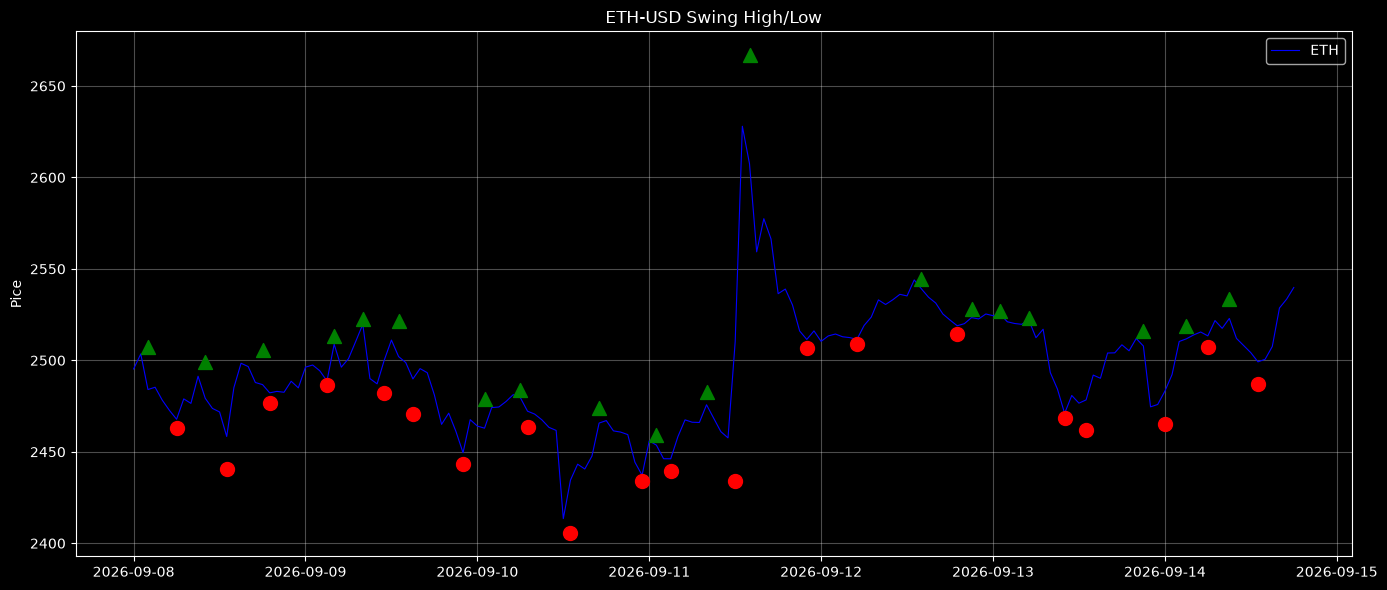

In [10]:
fig , ax = plt.subplots(figsize=(14, 6))
ax.plot(eth.index, eth['close'], color = "blue",linewidth = 0.8 ,label='ETH')
for i in swing_highs :
    ax.scatter(eth.index[i],eth["high"].iloc[i],
               color = "green",
               marker = "^",s = 100,
               zorder = 5)
for i in swing_lows :
    ax.scatter(eth.index[i],eth["low"].iloc[i],
               color = "red",
               marker = "o",s = 100,
               zorder = 5)
ax.set_title("ETH-USD Swing High/Low")
ax.set_ylabel("Pice")
ax.grid(True,alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()




In [17]:
# BOS detect
bos_bullish = []
bos_bearish = []
for i in range(1,len(eth)) :
    prev_highs = [ h for h in swing_highs if h < i]
    prev_lows = [l for l in swing_lows if l < i]
    if prev_highs :
        last_high = eth["high"].iloc[prev_highs[-1]]
        if eth["close"].iloc[i] > last_high:
            bos_bullish.append(i)

    if prev_lows :
        last_low = eth["low"].iloc[prev_lows[-1]]
        if eth["close"].iloc[i] < last_low:
            bos_bearish.append(i)

print(f"Bullish BOS : {len(bos_bullish)}")
print(f"Bearish BOS : {len(bos_bearish)}")

Bullish BOS : 15
Bearish BOS : 13


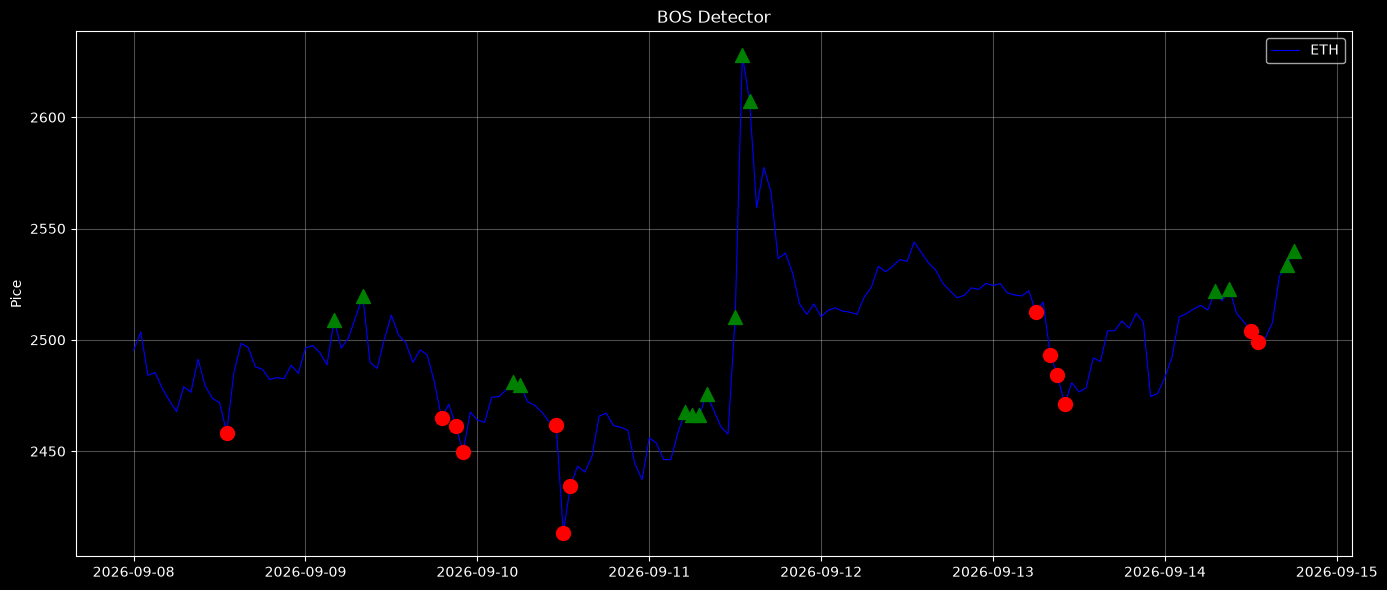

In [18]:
fig , ax = plt.subplots(figsize=(14, 6))
ax.plot(eth.index ,eth["close"], color = "blue",linewidth = 0.8 ,label='ETH')
for i in bos_bullish :
    ax.scatter(eth.index[i],eth["close"].iloc[i],color = "green",marker = "^",s = 100,zorder = 5)
for i in bos_bearish :
    ax.scatter(eth.index[i],eth["close"].iloc[i],color = "red",marker = "o",s = 100,zorder = 5)

ax.set_title("BOS Detector")
ax.set_ylabel("Pice")
ax.grid(True,alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
# CHoCH detect
choch_bullish = []
choch_bearish = []
trend = None
for i in range(1,len(eth)) :
    prev_highs = [h for h in swing_highs if h < i]
    prev_lows = [l for l in swing_lows if l < i]
    if prev_highs and prev_lows:
        last_high = eth["high"].iloc[prev_highs[-1]]
        last_low = eth["low"].iloc[prev_lows[-1]]
        if eth["close"].iloc[i] > last_high:
            if trend == "bearish" :
                choch_bullish.append(i)
            trend = "bullish"
        elif eth["close"].iloc[i] < last_low:
            if trend == "bullish" :
                choch_bearish.append(i)
            trend = "bearish"
print(f"CHoCH Bullish : {len(choch_bullish)}")
print(f"CHoCH Bearish : {len(choch_bearish)}")




CHoCH Bullish : 5
CHoCH Bearish : 4


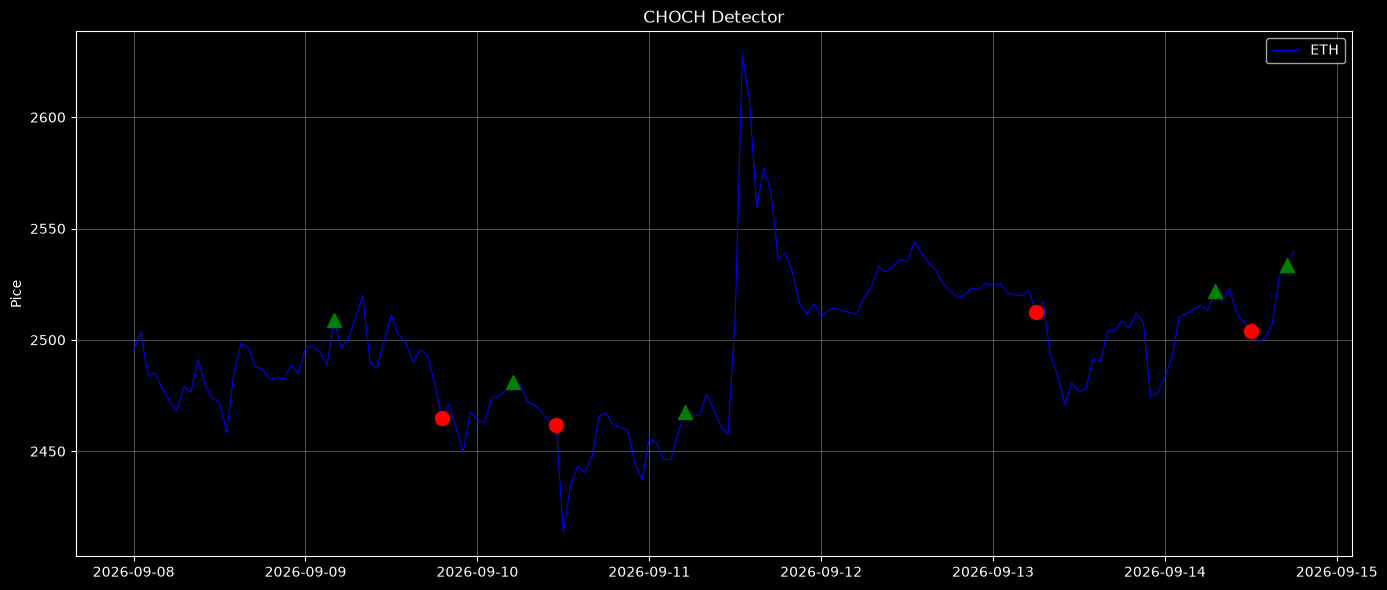

In [24]:
fig , ax = plt.subplots(figsize=(14, 6))
ax.plot(eth.index, eth["close"], color = "blue",linewidth = 0.8 ,label='ETH')
for i in choch_bullish :
    ax.scatter(eth.index[i],eth["close"].iloc[i],color = "green",marker = "^",s = 100,zorder = 5)
for i in choch_bearish :
    ax.scatter(eth.index[i],eth["close"].iloc[i],color = "red",marker = "o",s = 100,zorder = 5)
ax.set_title("CHOCH Detector")
ax.set_ylabel("Pice")
ax.grid(True,alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


In [25]:
# Liquidity Zones
buy_liquidity = [eth["high"].iloc[1] for i in swing_highs]
sell_liquidity = [eth["low"].iloc[1] for i in swing_lows]
print(f"BUY LIQUIDITY : {len(buy_liquidity)}")
print(f"SELL LIQUIDITY : {len(sell_liquidity)}")

BUY LIQUIDITY : 19
SELL LIQUIDITY : 20


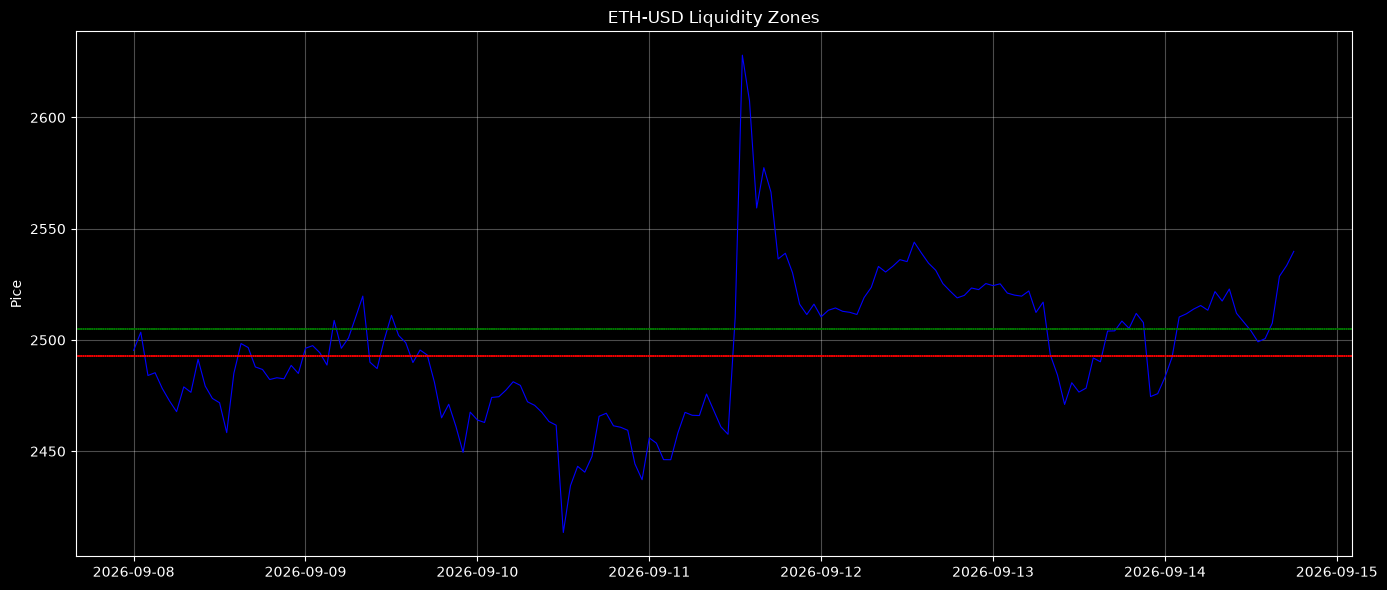

In [32]:
fig , ax = plt.subplots(figsize=(14, 6))
ax.plot(eth.index, eth["close"], color = "blue",linewidth = 0.8 ,label='ETH')
for i , level in zip(swing_highs, buy_liquidity) :
    ax.axhline(y=level,linestyle="dashed",color="green",linewidth = 0.3,alpha = 0.7,label="BUY LIQUIDITY")
for i , level in zip(swing_lows, sell_liquidity) :
    ax.axhline(y=level, color ="red",linestyle="dashed",linewidth =0.3 ,alpha = 0.7,label="SELL LIQUIDITY")

ax.set_title("ETH-USD Liquidity Zones")
ax.set_ylabel("Pice")
ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()


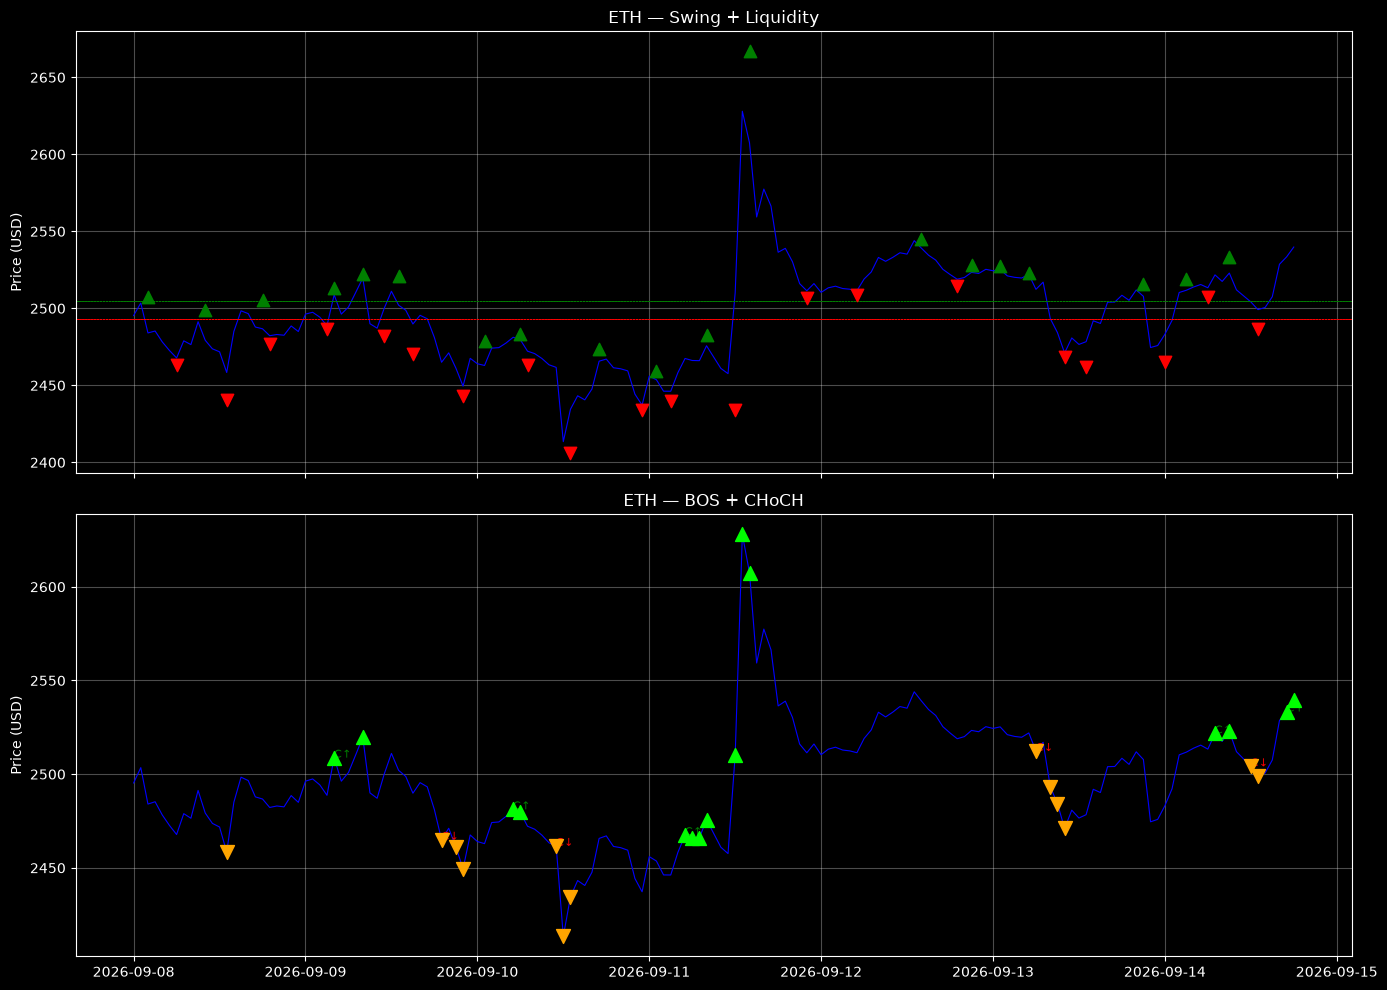

In [36]:
# Merge Charts
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Chart 1 — Price + Swing + Liquidity
ax1.plot(eth.index, eth['close'], color='blue', linewidth=0.8)
for i in swing_highs:
    ax1.scatter(eth.index[i], eth['high'].iloc[i], color='green', marker='^', s=80, zorder=5)
for i in swing_lows:
    ax1.scatter(eth.index[i], eth['low'].iloc[i], color='red', marker='v', s=80, zorder=5)
for i, level in zip(swing_highs, buy_liquidity):
    ax1.axhline(y=level, color='green', linestyle='--', linewidth=0.4, alpha=0.5)
for i, level in zip(swing_lows, sell_liquidity):
    ax1.axhline(y=level, color='red', linestyle='--', linewidth=0.4, alpha=0.5)
ax1.set_title('ETH — Swing + Liquidity')
ax1.set_ylabel('Price (USD)')
ax1.grid(True, alpha=0.3)

# Chart 2 — BOS + CHoCH
ax2.plot(eth.index, eth['close'], color='blue', linewidth=0.8)
for i in bos_bullish:
    ax2.scatter(eth.index[i], eth['close'].iloc[i], color='lime', marker='^', s=100, zorder=5, label='BOS Bull')
for i in bos_bearish:
    ax2.scatter(eth.index[i], eth['close'].iloc[i], color='orange', marker='v', s=100, zorder=5, label='BOS Bear')
for i in choch_bullish:
    ax2.annotate('C↑', xy=(eth.index[i], eth['close'].iloc[i]), color='green', fontsize=8)
for i in choch_bearish:
    ax2.annotate('C↓', xy=(eth.index[i], eth['close'].iloc[i]), color='red', fontsize=8)
ax2.set_title('ETH — BOS + CHoCH')
ax2.set_ylabel('Price (USD)')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()